<a href="https://colab.research.google.com/github/thvsbg/PyTorch/blob/main/02_Pytorch_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles
n_samples=1000
X,y=make_circles(1000,noise=0.03,random_state=42)
print(len(X),len(y))

1000 1000


In [3]:
print(X[:10])
print("y")
print(y[:10])

[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]
 [-0.47964637  0.67643477]
 [-0.01364836  0.80334872]
 [ 0.77151327  0.14775959]
 [-0.16932234 -0.79345575]
 [-0.1214858   1.02150905]]
y
[1 1 1 1 0 1 1 1 1 0]


In [4]:
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":y})
print(circles)

           X1        X2  label
0    0.754246  0.231481      1
1   -0.756159  0.153259      1
2   -0.815392  0.173282      1
3   -0.393731  0.692883      1
4    0.442208 -0.896723      0
..        ...       ...    ...
995  0.244054  0.944125      0
996 -0.978655 -0.272373      0
997 -0.136900 -0.810012      1
998  0.670362 -0.767502      0
999  0.281057  0.963824      0

[1000 rows x 3 columns]


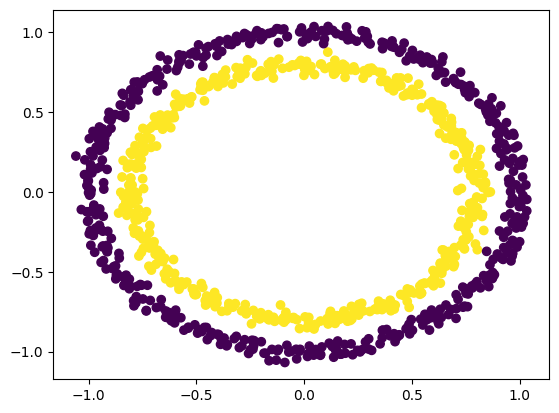

In [5]:
import matplotlib.pyplot as plt
plt.scatter(circles["X1"],circles["X2"],c=y)
plt.show()

In [6]:
X.shape

(1000, 2)

In [7]:
import torch

In [8]:
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [9]:
##train and test sets
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
##Building a model
from torch import nn

##device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [11]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=5)
    self.layer_2=nn.Linear(in_features=5,out_features=1)

  def forward(self,x):
    return self.layer_2(self.layer_1(x))


model_0=CircleModelV0().to(device)
model_0


CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

Try to recreate the model using nn.Sequential.

In [12]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.2295, -0.4641],
                      [-0.1885, -0.1564],
                      [ 0.6379,  0.4344],
                      [-0.6512,  0.4660],
                      [ 0.3626, -0.3184]])),
             ('layer_1.bias',
              tensor([-0.0278, -0.0519, -0.3901,  0.2812, -0.2654])),
             ('layer_2.weight',
              tensor([[-0.0529,  0.2507, -0.2047, -0.0722,  0.3519]])),
             ('layer_2.bias', tensor([0.0051]))])

In [13]:
## loss function and optimizer

loss_fn=nn.BCEWithLogitsLoss() ##built-in sigmoid activation function
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


In [14]:
##defining accuracy
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [15]:
## logits to prediction probability to labels

with torch.inference_mode():
  y_logit=model_0(X_test[:5])
  y_pred=torch.round(torch.sigmoid(y_logit))

##check for equality
print(y_test[:5])
print(y_pred)
print(torch.eq(y_test[:5],y_pred.squeeze(1)))



tensor([1., 0., 1., 0., 1.])
tensor([[0.],
        [0.],
        [1.],
        [0.],
        [1.]])
tensor([False,  True,  True,  True,  True])


In [19]:
from numpy import test
##building train and test loops
torch.manual_seed(42)
epochs=10000

for epoch in range(epochs):

  model_0.train()

  y_logits=model_0(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ##testing
  model_0.eval()
  with torch.inference_mode():
    test_logits=model_0(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits,y_test)
    test_acc= accuracy_fn(y_test,test_pred) ##order is different from loss function of true and pred

  if epoch%1000==0:
    print(f'Epoch:{epoch} | Loss: {loss} |Accuracy:{acc}| Test Loss:{test_loss} | Test Accuracy:{test_acc}')

Epoch:0 | Loss: 0.6929798722267151 |Accuracy:51.0| Test Loss:0.6946790218353271 | Test Accuracy:46.0
Epoch:1000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:2000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:3000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:4000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:5000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:6000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:7000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:8000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6946795582771301 | Test Accuracy:46.0
Epoch:9000 | Loss: 0.6929798126220703 |Accuracy:51.0| Test Loss:0.6

In [20]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions,plot_decision_boundary

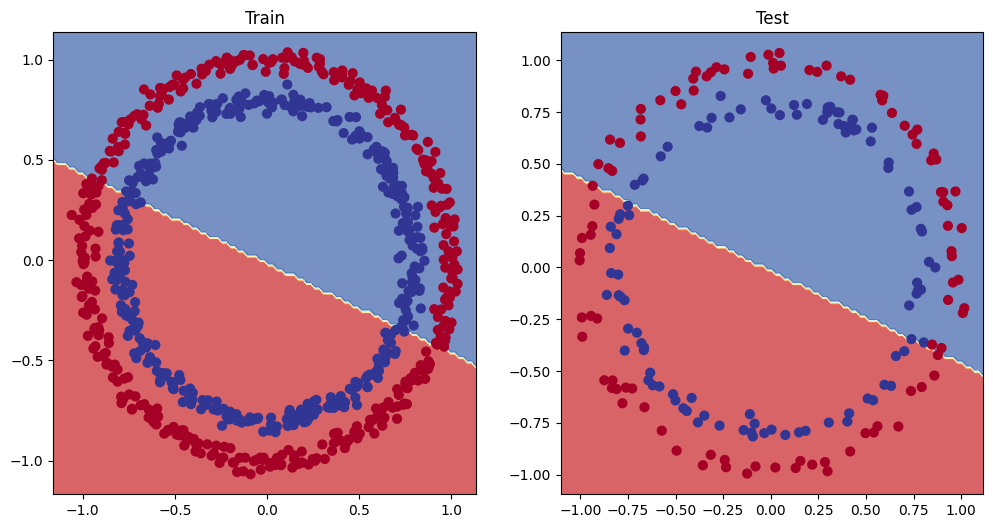

In [21]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

Improving from a model perspective

-> hidden units: 5->10
->epochs:100->1000


In [28]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2, out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)

  def forward(self,x):
    z=self.layer_1(x)
    z=self.layer_2(z)
    z=self.layer_3(z)
    return z
model_1=CircleModelV1()


In [24]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [30]:
torch.manual_seed(42)

epochs=1000

for epoch in range(epochs):
  model_1.train()
  y_logits=model_1(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ##testing
  model_1.eval()
  with torch.inference_mode():
    test_logits=model_1(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_test,test_pred)

  if epoch%100==0:
    print(f'Epoch:{epoch} | Loss:{loss} |Accuracy:{acc} |test_loss:{test_loss} | tes_acc:{test_acc}' )

Epoch:0 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:100 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:200 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:300 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:400 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:500 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:600 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:700 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:800 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0
Epoch:900 | Loss:0.6939550638198853 |Accuracy:50.875 |test_loss:0.6926102638244629 | tes_acc:51.0


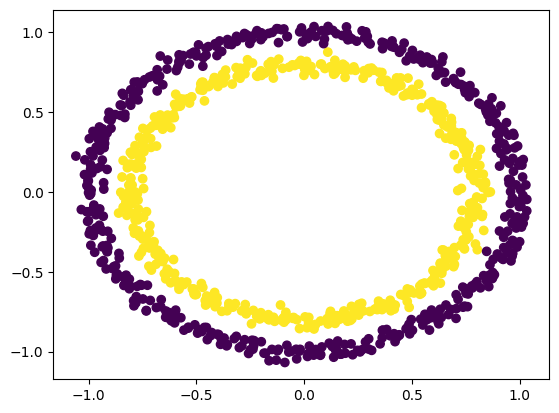

In [5]:
##recreating non-linear data

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples=1000

X,y=make_circles(n_samples,noise=0.03,random_state=42)

plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
import torch
from sklearn.model_selection import train_test_split

X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
## Build a model with non-linear activation functions

from torch import nn

class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1=nn.Linear(in_features=2,out_features=10)
    self.layer_2=nn.Linear(in_features=10,out_features=10)
    self.layer_3=nn.Linear(in_features=10,out_features=1)
    self.relu=nn.ReLU()

  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3=CircleModelV2()
model_3


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [10]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.SGD(params=model_3.parameters(),lr=0.1)

In [14]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_true))*100
  return acc

In [15]:
torch.manual_seed(42)
epochs=1000

for epoch in range(epochs):
  model_3.train()
  y_logits=model_3(X_train).squeeze()
  y_pred=torch.round(torch.sigmoid(y_logits))

  loss=loss_fn(y_logits,y_train)
  acc=accuracy_fn(y_train,y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ##testing
  model_3.eval()
  with torch.inference_mode():
    test_logits=model_3(X_test).squeeze()
    test_pred=torch.round(torch.sigmoid(test_logits))
    test_loss=loss_fn(test_logits,y_test)
    test_acc=accuracy_fn(y_test,test_pred)


  if epoch%100==0:
    print(f'loss:{loss} | accuracy:{acc} |test_loss:{test_loss} |test_acc:{test_acc}')




loss:0.693137526512146 | accuracy:50.0 |test_loss:0.6929333209991455 |test_acc:48.0
loss:0.6905169486999512 | accuracy:52.87500000000001 |test_loss:0.6910122632980347 |test_acc:50.5
loss:0.6873275637626648 | accuracy:63.24999999999999 |test_loss:0.6884477734565735 |test_acc:60.5
loss:0.6833713054656982 | accuracy:60.5 |test_loss:0.6850722432136536 |test_acc:57.49999999999999
loss:0.6767654418945312 | accuracy:60.375 |test_loss:0.6795079112052917 |test_acc:57.49999999999999
loss:0.6674426794052124 | accuracy:61.875 |test_loss:0.6711884140968323 |test_acc:58.5
loss:0.6534039378166199 | accuracy:71.125 |test_loss:0.6584143042564392 |test_acc:65.5
loss:0.6307665109634399 | accuracy:82.375 |test_loss:0.6363242864608765 |test_acc:77.5
loss:0.592210590839386 | accuracy:89.625 |test_loss:0.598612904548645 |test_acc:83.5
loss:0.5268132090568542 | accuracy:94.125 |test_loss:0.5334666967391968 |test_acc:90.0


Multiclass classifcation

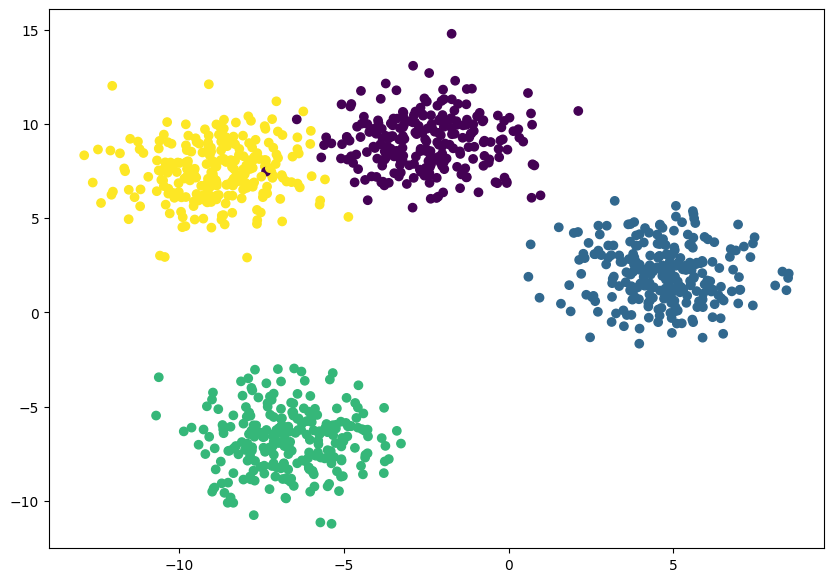

In [47]:
import torch
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42

X_blob,y_blob= make_blobs(n_samples=1000,n_features=NUM_FEATURES,centers=NUM_CLASSES,cluster_std=1.5,random_state=RANDOM_SEED)

##turn data from numpy to tensors
X_blob=torch.from_numpy(X_blob).type(torch.float)
y_blob=torch.from_numpy(y_blob).type(torch.LongTensor)

## split the data to train and test

X_blob_train,X_blob_test,y_blob_train,y_blob_test=train_test_split(X_blob,y_blob,test_size=0.2,random_state=RANDOM_SEED)

plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob)




In [18]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [54]:
print(X_blob.shape,y_blob.shape)
print(type(y_blob_test))
print(y_blob_test.dtype)
print(y_blob.dtype)

torch.Size([1000, 2]) torch.Size([1000])
<class 'torch.Tensor'>
torch.int64
torch.int64


In [26]:
import numpy as np
print(np.unique(y_blob))

[0. 1. 2. 3.]


In [40]:
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    super().__init__()
    self.linear_layer_stack=nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )
  def forward(self,x):
    return self.linear_layer_stack(x)

model_4=BlobModel(input_features=2,output_features=4)


In [41]:
loss_fn=nn.CrossEntropyLoss() ##there is a weight paramter which is used when there is an imbalance in the datasets. eg: 4 red dots, 50 blue dots, 100 green dots.

optimizer=torch.optim.SGD(params=model_4.parameters(),lr=0.1)

flow:
raw logits (forward pass)->pediction probabilies (passing trhough sigmoid and taking argmax)->prediction labels

In [56]:
epochs=100
torch.manual_seed(RANDOM_SEED)

for epoch in range(epochs):
  model_4.train()
  y_logits=model_4(X_blob_train).squeeze()
  y_pred_prob=torch.softmax(y_logits,dim=1)
  y_pred=torch.argmax(y_pred_prob,dim=1)


  loss=loss_fn(y_logits,y_blob_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ##testing
  model_4.eval()
  with torch.inference_mode():
    test_logits=model_4(X_blob_test).squeeze()
    test_pred_prob=torch.softmax(test_logits,dim=1)
    test_pred=torch.argmax(test_pred_prob,dim=1)

    test_loss=loss_fn(test_logits,y_blob_test)


  if epoch%10==0:
    print(f'loss:{loss} | test_loss:{test_loss}')


loss:0.0324619896709919 | test_loss:0.023584740236401558
loss:0.031084323301911354 | test_loss:0.022021086886525154
loss:0.030071942135691643 | test_loss:0.02081526257097721
loss:0.02928633615374565 | test_loss:0.019869545474648476
loss:0.028655527159571648 | test_loss:0.019113052636384964
loss:0.028138188645243645 | test_loss:0.018482631072402
loss:0.027702413499355316 | test_loss:0.01794997788965702
loss:0.027329254895448685 | test_loss:0.01748529262840748
loss:0.027006300166249275 | test_loss:0.0170766431838274
loss:0.026724182069301605 | test_loss:0.016711611300706863
